<a href="https://colab.research.google.com/github/PRANAV-MAGARDE/Odyssey/blob/main/odyssey1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'erayarising'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f5824c6bfc9fbe40d6dcc318bd6c7ccc'
%cd /content
!kaggle competitions download -c galaxy-zoo-the-galaxy-challenge

!unzip galaxy-zoo-the-galaxy-challenge.zip && unzip images_training_rev1.zip && rm *.zip

Streaming output truncated to the last 5000 lines.
  inflating: images_training_rev1/926425.jpg  
  inflating: images_training_rev1/926426.jpg  
  inflating: images_training_rev1/926435.jpg  
  inflating: images_training_rev1/926446.jpg  
  inflating: images_training_rev1/926448.jpg  
  inflating: images_training_rev1/926453.jpg  
  inflating: images_training_rev1/926462.jpg  
  inflating: images_training_rev1/926478.jpg  
  inflating: images_training_rev1/926480.jpg  
  inflating: images_training_rev1/926484.jpg  
  inflating: images_training_rev1/926488.jpg  
  inflating: images_training_rev1/926509.jpg  
  inflating: images_training_rev1/926522.jpg  
  inflating: images_training_rev1/926544.jpg  
  inflating: images_training_rev1/926547.jpg  
  inflating: images_training_rev1/926548.jpg  
  inflating: images_training_rev1/926551.jpg  
  inflating: images_training_rev1/926602.jpg  
  inflating: images_training_rev1/926630.jpg  
  inflating: images_training_rev1/926649.jpg  
  inflati

Streaming output truncated to the last 5000 lines.
178173.jpg  329682.jpg	476954.jpg  626682.jpg	775249.jpg  926425.jpg
178196.jpg  329689.jpg	476981.jpg  626718.jpg	775273.jpg  926426.jpg
178261.jpg  329720.jpg	477003.jpg  626741.jpg	775308.jpg  926435.jpg
178271.jpg  329736.jpg	477013.jpg  626742.jpg	775321.jpg  926446.jpg
178276.jpg  329752.jpg	477016.jpg  626748.jpg	775335.jpg  926448.jpg
178305.jpg  329754.jpg	477023.jpg  626757.jpg	775344.jpg  926453.jpg
178358.jpg  329786.jpg	477039.jpg  626770.jpg	775351.jpg  926462.jpg
178391.jpg  329807.jpg	477057.jpg  626787.jpg	775352.jpg  926478.jpg
178400.jpg  329813.jpg	477058.jpg  626793.jpg	775384.jpg  926480.jpg
178410.jpg  329818.jpg	477077.jpg  626796.jpg	775405.jpg  926484.jpg
178422.jpg  329835.jpg	477087.jpg  626800.jpg	775413.jpg  926488.jpg
178434.jpg  329866.jpg	477103.jpg  626804.jpg	775416.jpg  926509.jpg
178451.jpg  329875.jpg	477132.jpg  626808.jpg	775448.jpg  926522.jpg
178454.jpg  329878.jpg	477139.jpg  626821.jpg	775450

In [ ]:
import torch, os, cv2
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import torch.nn as nn

os.environ['KAGGLE_USERNAME'] = 'erayarising'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f5824c6bfc9fbe40d6dcc318bd6c7ccc'
%cd /content
!kaggle competitions download -c galaxy-zoo-the-galaxy-challenge

!unzip galaxy-zoo-the-galaxy-challenge.zip && unzip images_training_rev1.zip && rm *.zip
!ls /content/images_training_rev1   #ls makes list and ! opens terminal cmd

def clean_data(input_csv, clean_galaxy_labels, threshold):
    input= pd.read_csv(input_csv)
    input = input[['GalaxyID', 'Class1.1', 'Class1.2', 'Class1.3']] #Class 1.1 for elliptical and 1.2 for spiral galaxies; .3 was for uncertain/ stars

    mask = input['Class1.3'] < 0.5
    input = input[mask]
    input['Label'] = -1

    input.loc[input['Class1.2'] >= threshold, 'Label'] = 1
    input.loc[input['Class1.1'] >= threshold, 'Label'] = 0
    clean = input[input['Label'] != -1].copy()
    final = clean[['GalaxyID', 'Label']]
    final.to_csv(clean_galaxy_labels, index=False)
    return clean_galaxy_labels

class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8,8)): #init is a constructor: it runs whenever a new object is created
        self.clip_limit= clip_limit
        self.tile_grid_size= tile_grid_size
        self.clahe= None

    def __call__(self, img):
        if self.clahe is None:
            self.clahe= cv2.createCLAHE(self.clip_limit, self.tile_grid_size)

        img_np = np.array(img)
        lab_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b= cv2.split(lab_img)
        l_new = self.clahe.apply(l)
        lab_merged= cv2.merge((l_new, a, b))
        img_new = cv2.cvtColor(lab_merged, cv2.COLOR_LAB2RGB)

        return Image.fromarray(img_new)

astronomy_transforms = transforms.Compose([
    transforms.CenterCrop(250),
    transforms.Resize((224, 224)),

    ApplyCLAHE(),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class GalaxyZooDataset(Dataset):
    def __init__(self, csv_file, imgs, transforms):
        self.galaxy_frame = pd.read_csv(csv_file)
        self.imgs = imgs
        self.transform = transforms

    def __len__(self):
        return len(self.galaxy_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        galaxy_id = str(self.galaxy_frame.iloc[idx, 0])
        img_name = os.path.join(self.imgs, f"{galaxy_id}.jpg")

        image = Image.open(img_name).convert('RGB')
        label = self.galaxy_frame.iloc[idx, 1]

        image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct= 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss / len(loader), acc

def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0,0
    with torch.no_grad():
        for images,labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1)==labels).sum().item()

        acc = correct / len(loader.dataset)
        return total_loss / len(loader), acc


if __name__ == '__main__':
    images_path = '/content/images_training_rev1'

    if not os.path.exists('/content/drive'):
        print("Error: Google Drive is not mounted. Please mount it first (e.g., from the Files menu on the left).")
#    elif not os.path.isdir(images_path):
#        print(f"Error: The image directory does not exist or is not a directory: {images_path}")
#        print("Please check the path and ensure your Google Drive is correctly synchronized.")
    else:
        # Verify that there are actually image files in the directory
        image_files = [f for f in os.listdir(images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if not image_files:
            print(f"Error: No image files found in the directory: {images_path}")
            print("Please ensure your images are in the correct directory.")
        else:
            print(f"Found {len(image_files)} image files. First 5: {image_files[:5]}")

            galaxy_dataset = GalaxyZooDataset(csv_file=clean_data(input_csv= '/content/drive/MyDrive/training_solutions_rev1.csv',clean_galaxy_labels= 'clean_galaxy_labels.csv', threshold=0.8), imgs= images_path, transforms= astronomy_transforms)
            print("Data Loaded")

            train_size= int(0.8 * len(galaxy_dataset))
            test_size= len(galaxy_dataset) - train_size
            train_data, test_data = random_split(galaxy_dataset, [train_size, test_size])
            train_loader = DataLoader(train_data, batch_size=512, shuffle=True, num_workers=8, pin_memory=True)
            test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=8, pin_memory=True)


            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model = models.resnet50(weights='IMAGENET1K_V2')
            for param in model.parameters():
                param.requires_grad = False
            model.fc = nn.Linear(model.fc.in_features, 2)
            model = model.to(device)
            print("model done!")

            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

            print("training started")
            Epochs = 9
            for epoch in range(Epochs):
                train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
                val_loss, val_acc = val_epoch(model, test_loader, criterion, device)

                print(f"Epoch {epoch+1}/{Epochs} | "
                      f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

            torch.save(model.state_dict(), 'resnet50_galaxy.pth')
            print("Model Saved!")


Streaming output truncated to the last 5000 lines.
178261.jpg  329720.jpg	477003.jpg  626741.jpg	775308.jpg  926435.jpg
178271.jpg  329736.jpg	477013.jpg  626742.jpg	775321.jpg  926446.jpg
178276.jpg  329752.jpg	477016.jpg  626748.jpg	775335.jpg  926448.jpg
178305.jpg  329754.jpg	477023.jpg  626757.jpg	775344.jpg  926453.jpg
178358.jpg  329786.jpg	477039.jpg  626770.jpg	775351.jpg  926462.jpg
178391.jpg  329807.jpg	477057.jpg  626787.jpg	775352.jpg  926478.jpg
178400.jpg  329813.jpg	477058.jpg  626793.jpg	775384.jpg  926480.jpg
178410.jpg  329818.jpg	477077.jpg  626796.jpg	775405.jpg  926484.jpg
178422.jpg  329835.jpg	477087.jpg  626800.jpg	775413.jpg  926488.jpg
178434.jpg  329866.jpg	477103.jpg  626804.jpg	775416.jpg  926509.jpg
178451.jpg  329875.jpg	477132.jpg  626808.jpg	775448.jpg  926522.jpg
178454.jpg  329878.jpg	477139.jpg  626821.jpg	775450.jpg  926544.jpg
178456.jpg  329882.jpg	477161.jpg  626847.jpg	775457.jpg  926547.jpg
178478.jpg  329904.jpg	477170.jpg  626850.jpg	775464

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


model done!
training started


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/9 | Train Loss: 0.4752  Train Acc: 0.7829 | Val Loss: 0.3636  Val Acc: 0.8696
Epoch 2/9 | Train Loss: 0.3280  Train Acc: 0.8785 | Val Loss: 0.3107  Val Acc: 0.8822
Epoch 3/9 | Train Loss: 0.2875  Train Acc: 0.8937 | Val Loss: 0.2814  Val Acc: 0.8962
Epoch 4/9 | Train Loss: 0.2653  Train Acc: 0.9014 | Val Loss: 0.2620  Val Acc: 0.9050
Epoch 5/9 | Train Loss: 0.2519  Train Acc: 0.9075 | Val Loss: 0.2504  Val Acc: 0.9114
Epoch 6/9 | Train Loss: 0.2440  Train Acc: 0.9101 | Val Loss: 0.2391  Val Acc: 0.9164
Epoch 7/9 | Train Loss: 0.2369  Train Acc: 0.9132 | Val Loss: 0.2337  Val Acc: 0.9139
Epoch 8/9 | Train Loss: 0.2286  Train Acc: 0.9156 | Val Loss: 0.2282  Val Acc: 0.9153
Epoch 9/9 | Train Loss: 0.2271  Train Acc: 0.9161 | Val Loss: 0.2298  Val Acc: 0.9151
Model Saved!


In [ ]:
!cp /content/resnet50_galaxy.pth /content/drive/MyDrive/

Saving 100204.jpg to 100204.jpg


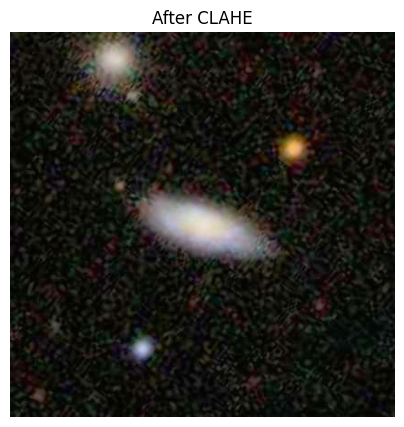

Image: 100204.jpg
Prediction: Spiral
Confidence: 77.37%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt

images_path = '/content/images_training_rev1'
            galaxy_dataset = GalaxyZooDataset(csv_file=clean_data(input_csv= '/content/drive/MyDrive/training_solutions_rev1.csv',clean_galaxy_labels= 'clean_galaxy_labels.csv', threshold=0.8), imgs= images_path, transforms= astronomy_transforms)
            print("Data Loaded")

            train_size= int(0.8 * len(galaxy_dataset))
            test_size= len(galaxy_dataset) - train_size
            train_data, test_data = random_split(galaxy_dataset, [train_size, test_size])
            train_loader = DataLoader(train_data, batch_size=512, shuffle=True, num_workers=8, pin_memory=True)
            test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=8, pin_memory=True)

# ── Load Model ────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/resnet50_galaxy.pth', map_location=device))
model.eval().to(device)

class_names = ['Elliptical', 'Spiral']
with torch.no_grad():
        output = model(tensor)
        prob   = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()
# ── Upload & Predict ──────────────────────────────────────────
uploaded = files.upload()  # opens file picker

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')

    img_np = np.array(img)
    grid_size = (8, 8) # default OpenCV tile grid size
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

# Apply CLAHE to each channel individually
    cl_r = clahe.apply(img_np[:, :, 0])
    cl_g = clahe.apply(img_np[:, :, 1])
    cl_b = clahe.apply(img_np[:, :, 2])
    img_clahe = np.stack([cl_r, cl_g, cl_b], axis=-1)

# Display the processed image
    plt.figure(figsize=(5, 5))
    plt.imshow(img_clahe)
    plt.title("After CLAHE")
    plt.axis('off')
    plt.show()

# Convert back to PIL Image so your existing transform pipeline works
    img = Image.fromarray(img_clahe)

    transform = transforms.Compose([
        transforms.CenterCrop(250),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension

    with torch.no_grad():
        output = model(tensor)
        prob   = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()

    print(f"Image: {filename}")
    print(f"Prediction: {class_names[pred]}")
    print(f"Confidence: {prob[0][pred].item()*100:.2f}%")

In [ ]:
from typing import ChainMap
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os # Added os import
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

images_path = '/content/images_training_rev1'
galaxy_dataset = GalaxyZooDataset(csv_file=clean_data(input_csv= '/content/drive/MyDrive/training_solutions_rev1.csv',clean_galaxy_labels= 'clean_galaxy_labels.csv', threshold=0.8), imgs= images_path, transforms= astronomy_transforms)
print("Data Loaded")

train_size= int(0.8 * len(galaxy_dataset))
test_size= len(galaxy_dataset) - train_size
train_data, test_data = random_split(galaxy_dataset, [train_size, test_size])
train_loader = DataLoader(train_data, batch_size=512, shuffle=True, num_workers=2, pin_memory=False)
test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=2, pin_memory=False)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

model_path = '/content/drive/MyDrive/resnet50_galaxy.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Model loaded successfully from {model_path}")
else:
    print(f"Warning: Model file not found at {model_path}. Please ensure your Google Drive is mounted and the file exists.")
    print("The model will proceed without pre-trained weights, which might lead to unexpected results.")

model.eval().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

val_loss, val_acc = val_epoch(model, test_loader, criterion, device)
all_labels, all_preds = [], []
with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(1).cpu().numpy()
    all_labels.extend(labels.cpu().numpy())
    all_preds.extend(preds)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
acc = (all_labels==all_preds).mean()
print(classification_report(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Spiral', 'Elliptical'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

NameError: name 'GalaxyZooDataset' is not defined

Saving 100204.jpg to 100204 (5).jpg


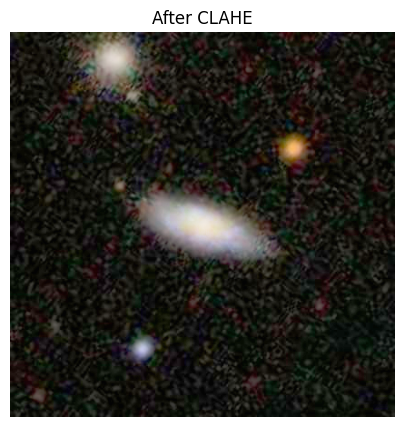

Image: 100204 (5).jpg
Prediction: Spiral
Confidence: 68.63%


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('/content/drive/MyDrive/resnet50_galaxy.pth', map_location=device))
model.eval().to(device)

class_names = ['Elliptical', 'Spiral']

uploaded = files.upload()  # opens file picker

for filename in uploaded.keys():
    img = Image.open(filename).convert('RGB')

    img_np = np.array(img)
    grid_size = (8, 8) # default OpenCV tile grid size
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))

    cl_r = clahe.apply(img_np[:, :, 0])
    cl_g = clahe.apply(img_np[:, :, 1])
    cl_b = clahe.apply(img_np[:, :, 2])
    img_clahe = np.stack([cl_r, cl_g, cl_b], axis=-1)

    plt.figure(figsize=(5, 5))
    plt.imshow(img_clahe)
    plt.title("After CLAHE")
    plt.axis('off')
    plt.show()

    img = Image.fromarray(img_clahe)

    transform = transforms.Compose([
        transforms.CenterCrop(250),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    tensor = transform(img).unsqueeze(0).to(device)  # add batch dimension

    with torch.no_grad():
        output = model(tensor)
        prob   = torch.softmax(output, dim=1)
        pred   = output.argmax(1).item()

    print(f"Image: {filename}")
    print(f"Prediction: {class_names[pred]}")
    print(f"Confidence: {prob[0][pred].item()*100:.2f}%")